In [ ]:
# Step 1: Load Data 

import pandas as pd

file_path = "../data/GlobalLandTemperaturesByCity.csv"

df = pd.read_csv(file_path, nrows=100000) 
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [15]:
# Step 2: BASIC ANALYSIS (First Thing Always)

import pandas as pd

def data_report(df):
    print("\n========== DATASET OVERVIEW ==========")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    print("\n========== COLUMN NAMES ==========")
    for col in df.columns:
        print(col)

    print("\n========== DATA INFO ==========")
    df.info()

    print("\n========== STATISTICAL SUMMARY ==========")
    print(df.describe().T)

    print("\n========== MISSING VALUES ==========")
    
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100

    for col in df.columns:
        if missing[col] > 0:
            print(f"{col} -> {missing[col]} missing ({missing_percent[col]:.2f}%)")


# call function
data_report(df)


========== DATASET OVERVIEW ==========
Rows: 100000, Columns: 7

========== COLUMN NAMES ==========
dt
AverageTemperature
AverageTemperatureUncertainty
City
Country
Latitude
Longitude

========== DATA INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   dt                             100000 non-null  datetime64[ns]
 1   AverageTemperature             100000 non-null  float64       
 2   AverageTemperatureUncertainty  100000 non-null  float64       
 3   City                           100000 non-null  object        
 4   Country                        100000 non-null  object        
 5   Latitude                       0 non-null       object        
 6   Longitude                      0 non-null       object        
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage

In [16]:
# Step 3: CLEANING (Think, don’t just code)

# Convert date
df['dt'] = pd.to_datetime(df['dt'])

# Fill missing temperature (better than dropping)
df['AverageTemperature'] = df.groupby('Country')['AverageTemperature'].transform(
    lambda x: x.fillna(x.mean())
)

df['AverageTemperatureUncertainty'] = df.groupby('Country')['AverageTemperatureUncertainty'].transform(
    lambda x: x.fillna(x.mean())
)

# Convert coordinates
def convert_coord(coord):
    if isinstance(coord, str):
        if coord.endswith(('N', 'E')):
            return float(coord[:-1])
        else:
            return -float(coord[:-1])
    return None

df['Latitude'] = df['Latitude'].apply(convert_coord)
df['Longitude'] = df['Longitude'].apply(convert_coord)



In [17]:
df

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068000,1.73700,Århus,Denmark,None,None
1,1743-12-01,7.695135,1.66872,Århus,Denmark,None,None
2,1744-01-01,7.695135,1.66872,Århus,Denmark,None,None
3,1744-02-01,7.695135,1.66872,Århus,Denmark,None,None
4,1744-03-01,7.695135,1.66872,Århus,Denmark,None,None
...,...,...,...,...,...,...,...
99995,1988-10-01,26.529000,0.21500,Agboville,Côte D'Ivoire,None,None
99996,1988-11-01,26.996000,0.38800,Agboville,Côte D'Ivoire,None,None
99997,1988-12-01,25.748000,0.20000,Agboville,Côte D'Ivoire,None,None
99998,1989-01-01,26.503000,0.43100,Agboville,Côte D'Ivoire,None,None


<Axes: xlabel='year'>

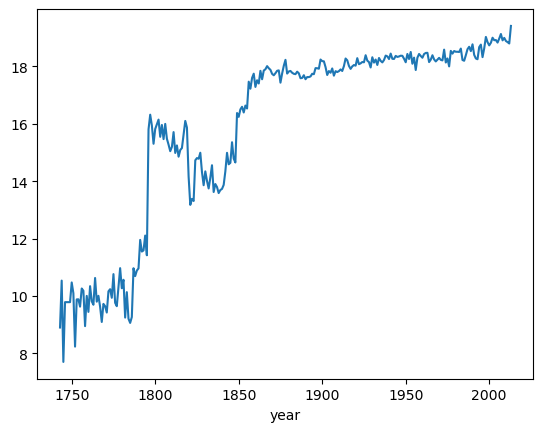

In [18]:
# Step 4: EDA (REAL ANALYSIS THINKING)

df['year'] = df['dt'].dt.year
df.groupby('year')['AverageTemperature'].mean().plot()

In [19]:
# Which countries are hottest?

df.groupby('Country')['AverageTemperature'].mean().sort_values(ascending=False).head(10)

Country
Venezuela               27.131416
Benin                   27.121563
United Arab Emirates    26.572681
Nigeria                 26.438146
Ghana                   26.287348
Côte D'Ivoire           26.219508
India                   26.035266
Indonesia               26.030282
Yemen                   25.547787
Iran                    25.034749
Name: AverageTemperature, dtype: float64

<Axes: >

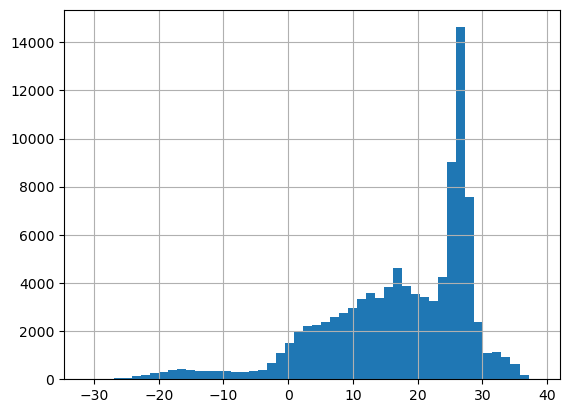

In [20]:
# Distribution:

df['AverageTemperature'].hist(bins=50)

In [26]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import webbrowser
import os

# ── 1. GENERATE SAMPLE DATA (replace with your actual df) ────────────────────
np.random.seed(42)
n = 10000

latitude  = np.random.uniform(-90, 90, n)
longitude = np.random.uniform(-180, 180, n)

lat_factor  = np.cos(np.radians(latitude))
noise       = np.random.normal(0, 4, n)
temperature = -25 + lat_factor * 60 + noise

df = pd.DataFrame({
    'Latitude'          : latitude,
    'Longitude'         : longitude,
    'AverageTemperature': temperature
})

# ── 2. SAMPLE & PREP ──────────────────────────────────────────────────────────
sample = df.sample(10000, random_state=42).reset_index(drop=True)

t_min, t_max = sample['AverageTemperature'].min(), sample['AverageTemperature'].max()
norm         = (sample['AverageTemperature'] - t_min) / (t_max - t_min)
marker_sizes = 2 + norm * 7

# ── 3. BUILD FIGURE ───────────────────────────────────────────────────────────
fig = go.Figure(data=[go.Scatter3d(
    x=sample['Longitude'],
    y=sample['Latitude'],
    z=sample['AverageTemperature'],

    mode='markers',
    marker=dict(
        size       = marker_sizes,
        color      = sample['AverageTemperature'],
        colorscale = 'Inferno',
        opacity    = 0.85,
        colorbar   = dict(
            title      = dict(text="Temp (°C)", font=dict(size=13, color='white')),
            tickfont   = dict(color='white'),
            thickness  = 18,
            len        = 0.75,
            x          = 1.02,
            bgcolor    = 'rgba(0,0,0,0)',
            bordercolor= 'rgba(255,255,255,0.2)',
        ),
        line=dict(width=0),
    ),
    text=[
        f"🌍 Lat: {la:.2f}°<br>🌐 Lon: {lo:.2f}°<br>🌡️ Temp: {t:.1f} °C"
        for la, lo, t in zip(
            sample['Latitude'],
            sample['Longitude'],
            sample['AverageTemperature']
        )
    ],
    hovertemplate="%{text}<extra></extra>",
)])

# ── 4. LAYOUT  (✅ titlefont → title_font everywhere) ─────────────────────────
fig.update_layout(
    title=dict(
        text    = "🌡️ Global Average Temperature — 3D View",
        x       = 0.5,
        y       = 0.97,
        xanchor = 'center',
        font    = dict(size=22, color='white', family='Arial Black'),
    ),

    scene=dict(
        xaxis=dict(
            title           = "Longitude",
            title_font      = dict(color='#aaaaaa', size=12),   # ✅ FIXED
            tickfont        = dict(color='#888888', size=9),
            gridcolor       = 'rgba(255,255,255,0.07)',
            backgroundcolor = 'rgb(10,10,20)',
            showbackground  = True,
            zerolinecolor   = 'rgba(255,255,255,0.15)',
        ),
        yaxis=dict(
            title           = "Latitude",
            title_font      = dict(color='#aaaaaa', size=12),   # ✅ FIXED
            tickfont        = dict(color='#888888', size=9),
            gridcolor       = 'rgba(255,255,255,0.07)',
            backgroundcolor = 'rgb(10,10,20)',
            showbackground  = True,
            zerolinecolor   = 'rgba(255,255,255,0.15)',
        ),
        zaxis=dict(
            title           = "Avg Temp (°C)",
            title_font      = dict(color='#aaaaaa', size=12),   # ✅ FIXED
            tickfont        = dict(color='#888888', size=9),
            gridcolor       = 'rgba(255,255,255,0.07)',
            backgroundcolor = 'rgb(10,10,20)',
            showbackground  = True,
            zerolinecolor   = 'rgba(255,80,0,0.4)',
        ),
        bgcolor='rgb(5,5,15)',
        camera=dict(
            eye=dict(x=1.6, y=1.6, z=0.8),
            up =dict(x=0,   y=0,   z=1),
        ),
    ),

    paper_bgcolor = 'rgb(5,5,15)',
    plot_bgcolor  = 'rgb(5,5,15)',
    margin        = dict(l=0, r=0, t=60, b=0),

    annotations=[dict(
        text=(
            f"<b>Points:</b> {len(sample):,}  │  "
            f"<b>Min:</b> {t_min:.1f}°C  │  "
            f"<b>Max:</b> {t_max:.1f}°C  │  "
            f"<b>Mean:</b> {sample['AverageTemperature'].mean():.1f}°C"
        ),
        xref='paper', yref='paper',
        x=0.5, y=0.01,
        xanchor  = 'center',
        showarrow= False,
        font     = dict(size=11, color='#888888'),
        bgcolor  = 'rgba(255,255,255,0.04)',
        bordercolor = 'rgba(255,255,255,0.1)',
        borderwidth = 1,
        borderpad   = 6,
    )],
)

# ── 5. SAVE & OPEN ────────────────────────────────────────────────────────────
output_path = os.path.join(os.getcwd(), "temperature_3d.html")
fig.write_html(output_path, full_html=True, include_plotlyjs='cdn',
               config={'scrollZoom': True, 'displaylogo': False})

print(f"✅ Chart saved → {output_path}")
webbrowser.open(f"file://{output_path}")

# In Jupyter just run:  fig.show()

✅ Chart saved → c:\Users\LENOVO\OneDrive\Desktop\climate_analysis\Notebook\temperature_3d.html


True

In [33]:
import plotly.express as px

print(f"Total rows: {len(df)}")
print(df.head(2))

# Sample
df_sample = df.dropna().sample(n=min(10000, len(df)), random_state=42)

# Plot (no animation_frame since there's no date column)
fig = px.scatter_3d(
    df_sample,
    x='Longitude',
    y='Latitude',
    z='AverageTemperature',
    color='AverageTemperature',
    color_continuous_scale='plasma',
    opacity=0.7,
    hover_data={'AverageTemperature': ':.2f', 'Latitude': ':.4f', 'Longitude': ':.4f'},
    title='Global Average Temperature Distribution',
    labels={'AverageTemperature': 'Avg Temp (°C)'}
)

fig.update_traces(marker=dict(size=2.5))

fig.update_layout(
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Avg Temp (°C)',
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8))
    ),
    coloraxis_colorbar=dict(title='Temp (°C)'),
    height=650,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

Total rows: 10000
    Latitude  Longitude  AverageTemperature
0 -22.582779 -45.489305           27.184328
1  81.128575 -60.151645          -13.402974
